# Stack Comparison: Are F0, F1, F2, F3 similar or different?

**QUESTION:** Which stacks are harder? Can we train together or need per-stack weighting?

**DECISION GATES:**
- Gain divergence > 1.5× → need per-stack weighting
- Active pixels < 5% → patch sampling broken
- τ(0.5) std > 10 → temporal assumptions stack-specific

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path
from load_data import load_all_stacks
from metrics import compute_results, compute_gains
from plots import plot_stacks_side_by_side, plot_gain_slopes
from analysis import print_summary_table, analyze_and_recommend

DATA = Path("../../data/val")

## Load stacks

In [2]:
stacks = load_all_stacks(DATA)

Loaded F0: (1500, 490, 490)
Loaded F1: (1500, 490, 490)
Loaded F2: (1500, 490, 490)
Loaded F3: (1500, 490, 490)


## Compute metrics

In [3]:
f0_ref = stacks["F0"]
results = compute_results(stacks, f0_ref)


F0:
  Mean intensity: 204.5
  Mean variance: 2828.9
  Active pixels: 25.00%
  stSNR: 209.086
  τ(0.5): 0.7 frames

F1:
  Mean intensity: 204.5
  Mean variance: 10994.2
  Active pixels: 25.00%
  stSNR: 7.274
  τ(0.5): 0.0 frames

F2:
  Mean intensity: 204.4
  Mean variance: 56322.9
  Active pixels: 25.00%
  stSNR: -0.794
  τ(0.5): 0.0 frames

F3:
  Mean intensity: 204.5
  Mean variance: 209293.2
  Active pixels: 25.00%
  stSNR: -6.639
  τ(0.5): 0.0 frames


## Compute gains

In [4]:
gains = compute_gains(stacks)

F0: gain = 304.5788
F1: gain = 331.9571
F2: gain = 554.3806
F3: gain = 1299.4385


## Visualizations

/home/sarpk/python-tools/denoising_calcium/workspace/notebooks/08_stack_comparison/plots.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


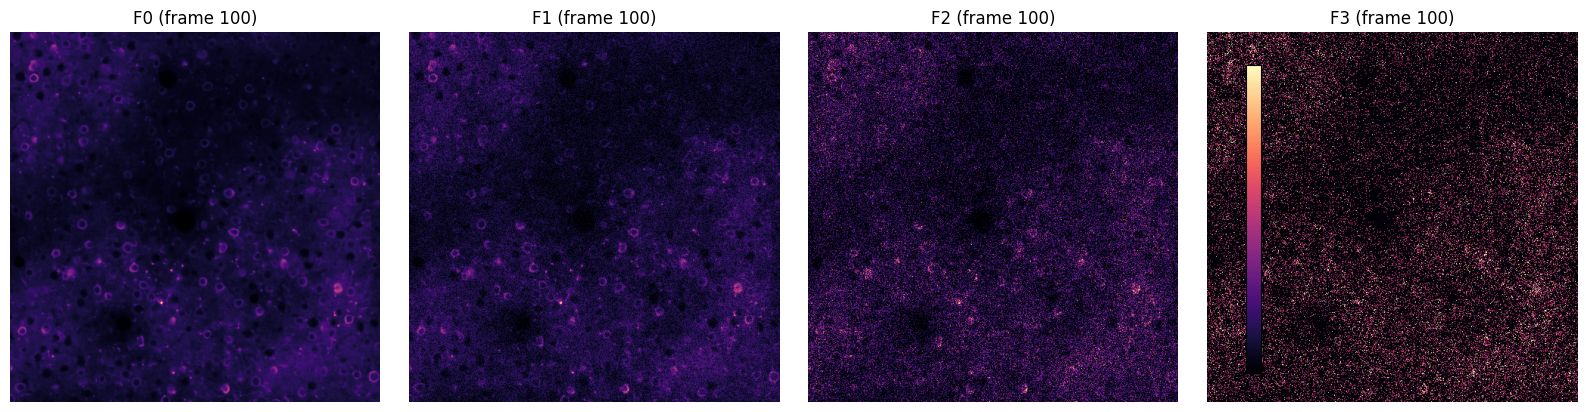

✓ All 4 stacks plotted at same frame and colorscale


In [5]:
plot_stacks_side_by_side(stacks, frame_idx=100, save_path="/tmp/stacks_side_by_side.png")

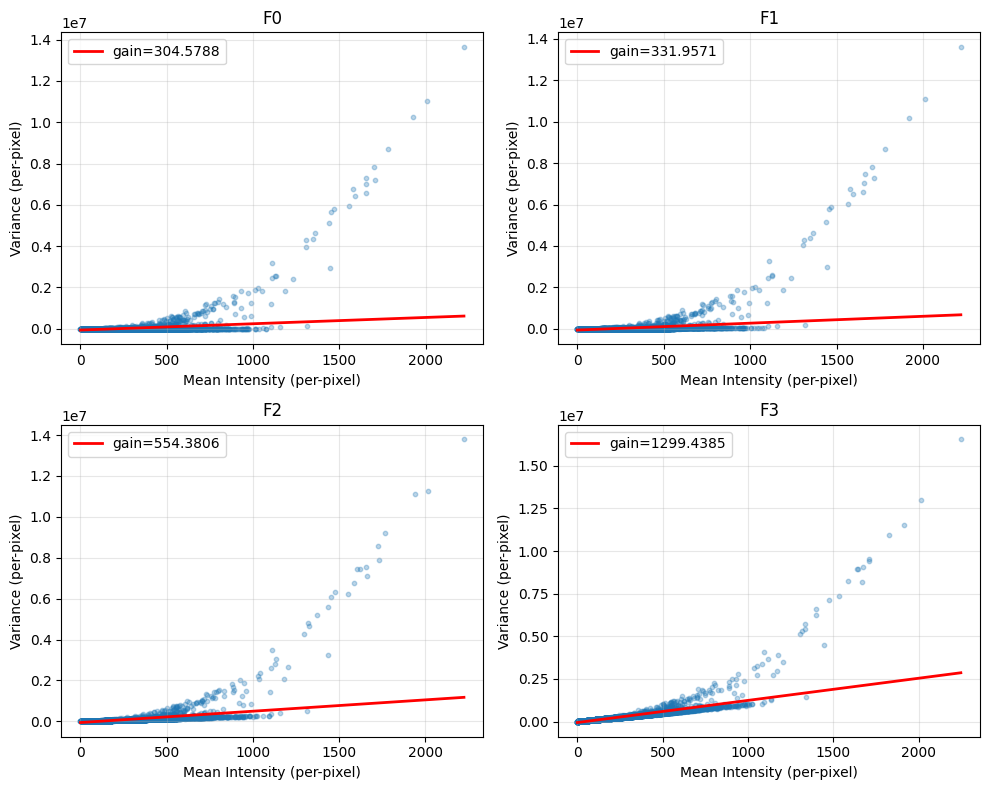

✓ Gain slopes plotted separately per stack


In [6]:
plot_gain_slopes(gains, save_path="/tmp/gain_slopes.png")

## Summary and analysis

In [7]:
print_summary_table(results, gains)


SUMMARY TABLE

| Stack | Mean Int | Mean Var | Active % | stSNR | sSNR | tSNR | τ(0.5) | Gain   |
|-------|----------|----------|----------|-------|------|------|--------|--------|
| F0     |    204.5 |   2828.9 |    25.00 | 209.086 | 221.026 | 197.147 |    0.7 | 304.5788 |
| F1     |    204.5 |  10994.2 |    25.00 | 7.274 | 8.096 | 6.452 |    0.0 | 331.9571 |
| F2     |    204.4 |  56322.9 |    25.00 | -0.794 | -0.069 | -1.520 |    0.0 | 554.3806 |
| F3     |    204.5 | 209293.2 |    25.00 | -6.639 | -5.935 | -7.343 |    0.0 | 1299.4385 |


In [8]:
analyze_and_recommend(results, gains)


ANALYSIS & RECOMMENDATIONS

1. GAIN VARIATION: 4.27× ratio
   Gains: ['304.5788', '331.9571', '554.3806', '1299.4385']
   ⚠ Stacks diverge → need PER-STACK weighting or wider augmentation

2. ACTIVE PIXELS (neurons): min = 25.00%
   ✓ Random patch sampling OK

3. RAW DIFFICULTY (stSNR for noisy stacks): -6.639
   ⚠ Very little headroom for improvement

4. TEMPORAL COHERENCE (τ): ['0.7', '0.0', '0.0', '0.0'], std = 0.3
   ✓ τ≈46 is UNIVERSAL across all stacks

RECOMMENDATION

⚠ PER-STACK STRATEGY RECOMMENDED
  - Gain diverges by 4.27×
  - Consider separate models or heavy per-stack weighting

